<a href="https://colab.research.google.com/github/Subashinie-dev/my-portfolio/blob/main/smartimageenhancement.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Upload an image (jpg/png)...


Saving jeni pic.jfif to jeni pic.jfif
Image size: (512, 384, 3)


,MSE,PSNR (dB)
Noisy (no filter),999.89,18.13
Gaussian,141.28,26.63
Median,108.38,27.78
Bilateral,516.72,21.00


Best filter (highest PSNR): Median
Enhanced image PSNR vs original: 21.07 dB


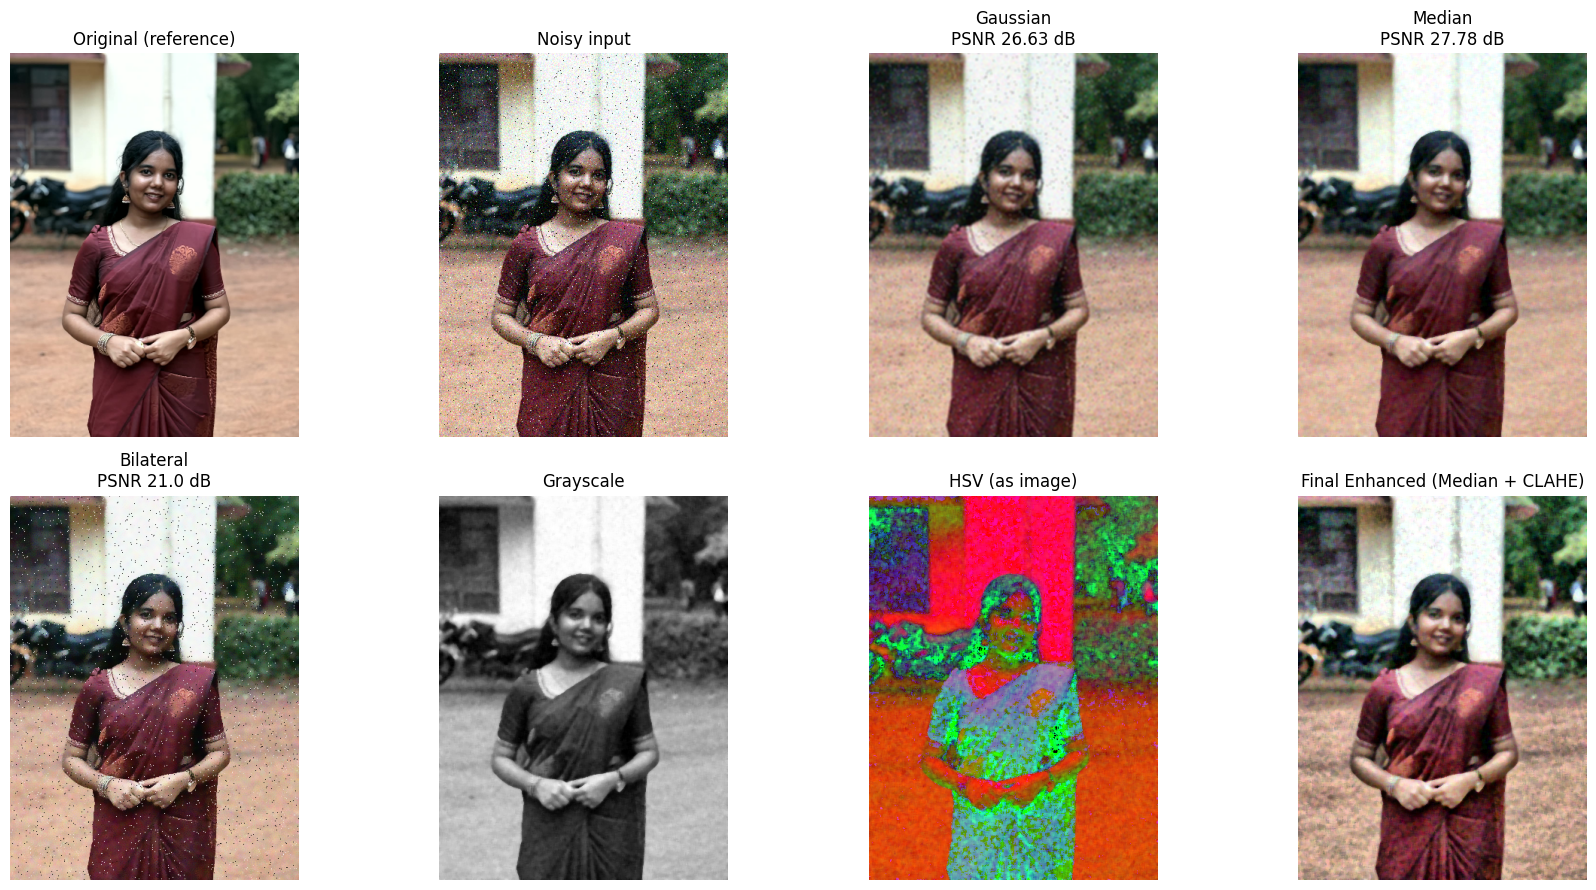

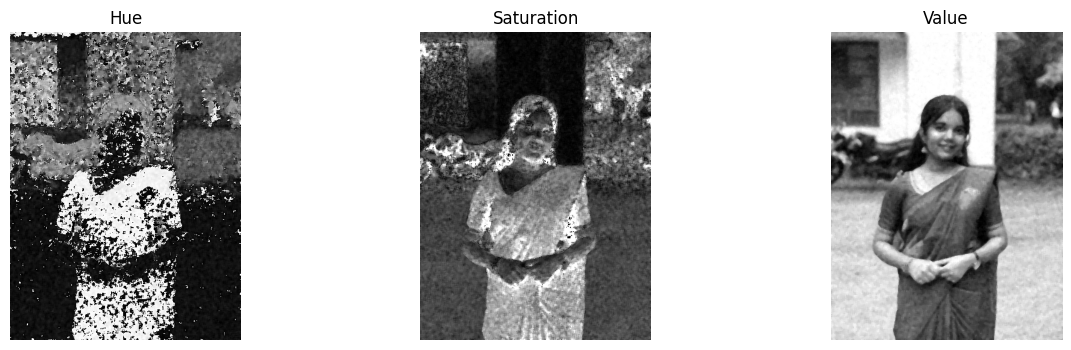

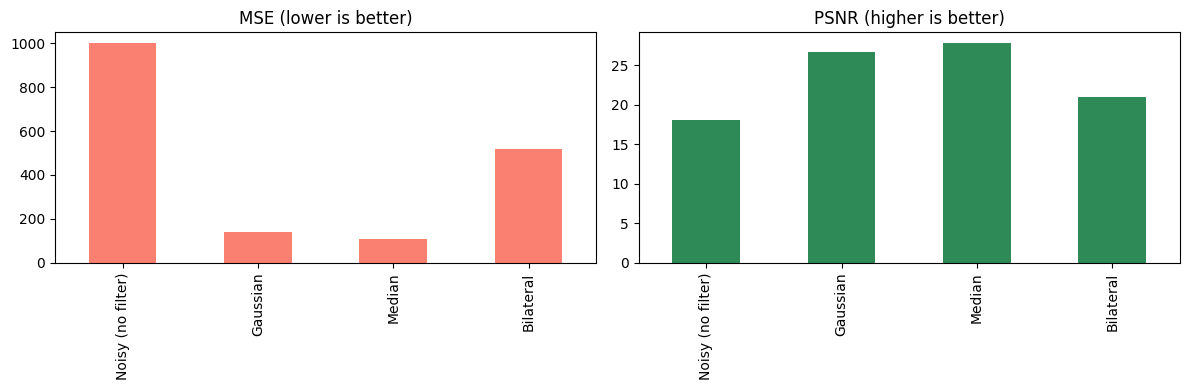

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [7]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

print("Upload an image (jpg/png)...")
uploaded = files.upload()
path = list(uploaded.keys())[0]

img = cv2.imread(path)                      # BGR format
h, w = img.shape[:2]
scale = 512 / max(h, w)                     # resize for faster processing
if scale < 1:
    img = cv2.resize(img, (int(w * scale), int(h * scale)))
print("Image size:", img.shape)

def add_noise(image, sigma=25, sp_amount=0.02):
    # Gaussian noise
    noisy = image.astype(np.float32) + np.random.normal(0, sigma, image.shape)
    noisy = np.clip(noisy, 0, 255).astype(np.uint8)
    # Salt & pepper noise
    mask = np.random.rand(*image.shape[:2])
    noisy[mask < sp_amount / 2] = 0
    noisy[mask > 1 - sp_amount / 2] = 255
    return noisy

np.random.seed(42)
noisy = add_noise(img)

gaussian  = cv2.GaussianBlur(noisy, (5, 5), 1.5)
median    = cv2.medianBlur(noisy, 5)
bilateral = cv2.bilateralFilter(noisy, d=9, sigmaColor=75, sigmaSpace=75)

best_input = bilateral                      # used here just for display
gray = cv2.cvtColor(best_input, cv2.COLOR_BGR2GRAY)
hsv  = cv2.cvtColor(best_input, cv2.COLOR_BGR2HSV)
H, S, V = cv2.split(hsv)

def mse(a, b):
    return np.mean((a.astype(np.float64) - b.astype(np.float64)) ** 2)

def psnr(a, b):
    m = mse(a, b)
    return float('inf') if m == 0 else 10 * np.log10((255.0 ** 2) / m)

results = {
    "Noisy (no filter)": noisy,
    "Gaussian":  gaussian,
    "Median":    median,
    "Bilateral": bilateral,
}

table = pd.DataFrame({
    "MSE":       [round(mse(img, r), 2) for r in results.values()],
    "PSNR (dB)": [round(psnr(img, r), 2) for r in results.values()],
}, index=results.keys())

best = table["PSNR (dB)"].drop("Noisy (no filter)").idxmax()
display(table)
print(f"Best filter (highest PSNR): {best}")


best_input = results[best]

gray = cv2.cvtColor(best_input, cv2.COLOR_BGR2GRAY)
hsv = cv2.cvtColor(best_input, cv2.COLOR_BGR2HSV)
H, S, V = cv2.split(hsv)

best_img = results[best]
hsv_b = cv2.cvtColor(best_img, cv2.COLOR_BGR2HSV)
h_, s_, v_ = cv2.split(hsv_b)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
v_eq = clahe.apply(v_)
enhanced = cv2.cvtColor(cv2.merge([h_, s_, v_eq]), cv2.COLOR_HSV2BGR)
print("Enhanced image PSNR vs original:", round(psnr(img, enhanced), 2), "dB")

rgb = lambda x: cv2.cvtColor(x, cv2.COLOR_BGR2RGB)

fig, ax = plt.subplots(2, 4, figsize=(18, 9))
items = [
    ("Original (reference)", rgb(img), None),
    ("Noisy input", rgb(noisy), None),
    (f"Gaussian\nPSNR {table.loc['Gaussian','PSNR (dB)']} dB", rgb(gaussian), None),
    (f"Median\nPSNR {table.loc['Median','PSNR (dB)']} dB", rgb(median), None),
    (f"Bilateral\nPSNR {table.loc['Bilateral','PSNR (dB)']} dB", rgb(bilateral), None),
    ("Grayscale", gray, "gray"),
    ("HSV (as image)", rgb(hsv), None),
    (f"Final Enhanced ({best} + CLAHE)", rgb(enhanced), None),
]
for a, (t, im, cm) in zip(ax.ravel(), items):
    a.imshow(im, cmap=cm); a.set_title(t); a.axis("off")
plt.tight_layout(); plt.show()

# HSV channels
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for a, ch, n in zip(ax, (H, S, V), ("Hue", "Saturation", "Value")):
    a.imshow(ch, cmap="gray"); a.set_title(n); a.axis("off")
plt.show()
# Bar charts
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
table["MSE"].plot.bar(ax=ax[0], color="salmon", title="MSE (lower is better)")
table["PSNR (dB)"].plot.bar(ax=ax[1], color="seagreen", title="PSNR (higher is better)")
plt.tight_layout(); plt.show()

cv2.imwrite("enhanced_output.png", enhanced)
files.download("enhanced_output.png")

